In [1]:
import math
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import numpy as np
import random

# functions

In [2]:
def sphere(x):
    """Mínimo global: f(0, ..., 0) = 0"""
    return sum(xi**2 for xi in x)

def rastrigin(x):
    """Mínimo global: f(0, ..., 0) = 0"""
    n = len(x)
    return 10 * n + sum(xi**2 - 10 * np.cos(2 * np.pi * xi) for xi in x)

def rosenbrock(x):
    """Mínimo global: f(1, ..., 1) = 0"""
    return sum(100 * (x[i+1] - x[i]**2)**2 + (x[i] - 1)**2 for i in range(len(x)-1))

# parameters

In [ ]:
DIMENSIONS = 30              # Número de dimensões do espaço de busca (DIM)
GLOBAL_BEST = 0              # Melhor valor global conhecido
CS = 30                      # Tamanho da Colônia (Colony Size)
CICLOS = 100                 # Número de iterações/ciclos do algoritmo
RANDOM_SEED = 42             # Semente aleatória para reprodutibilidade
EXECUTIONS = 30              # Número de execuções para cada função
CONVERGENCE = 1e-5           # Critério de convergência

# Cálculo dinâmico do fator de abandono conforme solicitado: ((CS / 2) * DIM) / 2 e ((CS / 2) * DIM) / 4
#FATOR_ABANDONO = ((CS / 2) * DIMENSIONS) / 2  
FATOR_ABANDONO = ((CS / 2) * DIMENSIONS) / 4

SELECTION_MODE = 'tournament' # Escolha entre 'roulette' (roleta) ou 'tournament' (torneio)
TOURNAMENT_SIZE = 3          # Quantidade de abelhas no torneio

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# bees

In [4]:
def get_fitness(value):
    """Calcula a aptidão: menores valores de custo resultam em maior fitness."""
    if value >= 0:
        return 1 / (value + 1)
    else:
        return 1 + abs(value)

def selection(bees, mode='roulette'):
    """Seleção de abelhas operárias pelas observadoras com base em Roleta ou Torneio."""
    if mode == 'roulette':
        fitnesses = [b.fitness for b in bees]
        total_fitness = sum(fitnesses)
        probs = [f / total_fitness for f in fitnesses]
        return np.random.choice(bees, p=probs)
    elif mode == 'tournament':
        competitors = random.sample(bees, TOURNAMENT_SIZE)
        return max(competitors, key=lambda b: b.fitness)

class Bee():
    def __init__(self, b_lo, b_hi, actual_function):
        self.b_lo = b_lo
        self.b_hi = b_hi
        self.actual_function = actual_function
        self.pos = np.random.uniform(b_lo, b_hi, DIMENSIONS)
        self.value = self.actual_function(self.pos)
        self.fitness = get_fitness(self.value)
        self.trials = 0

    def explore(self, target_pos, neighbor_pos):
        """
        Gera uma nova posição variando os dados da equação clássica do ABC:
        v_ij = x_ij + phi * (x_ij - x_kj)
        """
        new_pos = target_pos.copy()
        
        j = random.randint(0, DIMENSIONS - 1)
        phi = random.uniform(-1, 1)
        
        new_pos[j] = target_pos[j] + phi * (target_pos[j] - neighbor_pos[j])
        new_pos[j] = max(self.b_lo, min(self.b_hi, new_pos[j]))
        
        new_value = self.actual_function(new_pos)
        new_fitness = get_fitness(new_value)
        
        if new_fitness > self.fitness:
            self.pos = new_pos
            self.value = new_value
            self.fitness = new_fitness
            self.trials = 0
        else:
            self.trials += 1

    def reset(self):
        """Fase da Escoteira: Reinicializa se exceder o FATOR_ABANDONO."""
        self.pos = np.random.uniform(self.b_lo, self.b_hi, DIMENSIONS)
        self.value = self.actual_function(self.pos)
        self.fitness = get_fitness(self.value)
        self.trials = 0

# problem

In [ ]:
def artificial_bee_colony(selection_mode='roulette'):
    resultados_finais = {}

    for actual_function in [sphere, rastrigin, rosenbrock]:
        print(f"\n{'='*70}")
        print(f"INICIANDO TESTES PARA A FUNÇÃO: {actual_function.__name__.upper()}")
        print(f"{'='*70}\n")
        
        # Limites do espaço de busca
        if actual_function.__name__ == 'rastrigin':
            b_lo, b_hi = -5.12, 5.12
        elif actual_function.__name__ == 'rosenbrock':
            b_lo, b_hi = -30.0, 30.0
        else:
            b_lo, b_hi = -100.0, 100.0

        curvas_desta_funcao = []
        melhor_fitness_por_exec = [] # Armazena o melhor resultado de cada uma das 30 rodadas

        for execution in range(EXECUTIONS):
            convergence_curve = []
            
            seed_atual = RANDOM_SEED + execution
            random.seed(seed_atual)
            np.random.seed(seed_atual)
            
            # Divisão da colônia (Metade operárias, metade observadoras)
            num_employees = CS // 2
            employees = [Bee(b_lo, b_hi, actual_function) for _ in range(num_employees)]
            onlookers = [Bee(b_lo, b_hi, actual_function) for _ in range(CS - num_employees)]
            
            best_value = math.inf
            
            curr_iter = 0
            while curr_iter < CICLOS:
                
                # 1. Fase das Abelhas Operárias
                for i, bee in enumerate(employees):
                    k = random.choice([x for x in range(num_employees) if x != i])
                    neighbor_pos = employees[k].pos
                    bee.explore(target_pos=bee.pos, neighbor_pos=neighbor_pos)
                
                # 2. Fase das Abelhas Observadoras
                for bee in onlookers:
                    chosen_employee = selection(employees, mode=selection_mode)
                    k = random.randint(0, num_employees - 1)
                    neighbor_pos = employees[k].pos
                    bee.explore(target_pos=chosen_employee.pos, neighbor_pos=neighbor_pos)
                
                # 3. Fase das Escoteiras (Verifica o limite de abandono)
                for bee in employees + onlookers:
                    if bee.trials >= FATOR_ABANDONO:
                        bee.reset()
                        
                # 4. Atualiza a melhor solução global
                current_best = min(employees + onlookers, key=lambda b: b.value).value
                if current_best < best_value:
                    best_value = current_best
                    
                convergence_curve.append(best_value)
                
                # Critério de Parada Antecipada por Convergência
                if abs(best_value - GLOBAL_BEST) < CONVERGENCE:
                    resto_iters = CICLOS - curr_iter - 1
                    convergence_curve.extend([best_value] * resto_iters)
                    break
                    
                curr_iter += 1

            # Salvar resultados da execução
            curvas_desta_funcao.append(convergence_curve)
            melhor_fitness_por_exec.append(best_value)
            
            print(f"Execução {execution+1:02d}/{EXECUTIONS} (seed={seed_atual:3d}) | Melhor fitness final: {best_value:.2f}")
        
        # Calcular a média das curvas para o gráfico
        media_curvas = np.mean(curvas_desta_funcao, axis=0)
        resultados_finais[actual_function.__name__] = media_curvas
        
        # Impressão do Bloco Estatístico (Cópia exata do padrão do AG)
        print(f"\n{'='*60}")
        print(f"RESULTADOS FINAIS APÓS {EXECUTIONS} EXECUÇÕES - {actual_function.__name__.upper()}")
        print(f"{'='*60}")
        print(f"Melhor fitness geral:               {np.min(melhor_fitness_por_exec):.2f}")
        print(f"Pior fitness (máximo observado):    {np.max(melhor_fitness_por_exec):.2f}")
        print(f"Fitness médio:                      {np.mean(melhor_fitness_por_exec):.2f}")
        print(f"Desvio padrão:                      {np.std(melhor_fitness_por_exec):.2f}")
        print(f"Mediana:                            {np.median(melhor_fitness_por_exec):.2f}")

    # Geração dos gráficos ao final de todos os testes
    plt.figure(figsize=(10, 6))
    for nome_funcao, media_curva in resultados_finais.items():
        curva_segura = [max(val, 1e-10) for val in media_curva]
        plt.plot(curva_segura, label=nome_funcao.capitalize(), linewidth=2)

    plt.title(f"Curva de Convergência Média ABC ({EXECUTIONS} Execuções - {DIMENSIONS}D)")
    plt.xlabel("Iterações")
    plt.ylabel("Melhor Custo (Z) - Escala Log")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


INICIANDO TESTES PARA A FUNÇÃO: SPHERE

Execução 01/30 (seed= 42) | Melhor fitness final: 41080.69
Execução 02/30 (seed= 43) | Melhor fitness final: 47055.79
Execução 03/30 (seed= 44) | Melhor fitness final: 33351.95
Execução 04/30 (seed= 45) | Melhor fitness final: 51247.93
Execução 05/30 (seed= 46) | Melhor fitness final: 41912.60
Execução 06/30 (seed= 47) | Melhor fitness final: 53155.38
Execução 07/30 (seed= 48) | Melhor fitness final: 55200.30
Execução 08/30 (seed= 49) | Melhor fitness final: 47977.95
Execução 09/30 (seed= 50) | Melhor fitness final: 36339.09
Execução 10/30 (seed= 51) | Melhor fitness final: 45807.85
Execução 11/30 (seed= 52) | Melhor fitness final: 47387.29
Execução 12/30 (seed= 53) | Melhor fitness final: 46343.09
Execução 13/30 (seed= 54) | Melhor fitness final: 33255.54
Execução 14/30 (seed= 55) | Melhor fitness final: 35193.72
Execução 15/30 (seed= 56) | Melhor fitness final: 54008.99
Execução 16/30 (seed= 57) | Melhor fitness final: 47197.66
Execução 17/30 

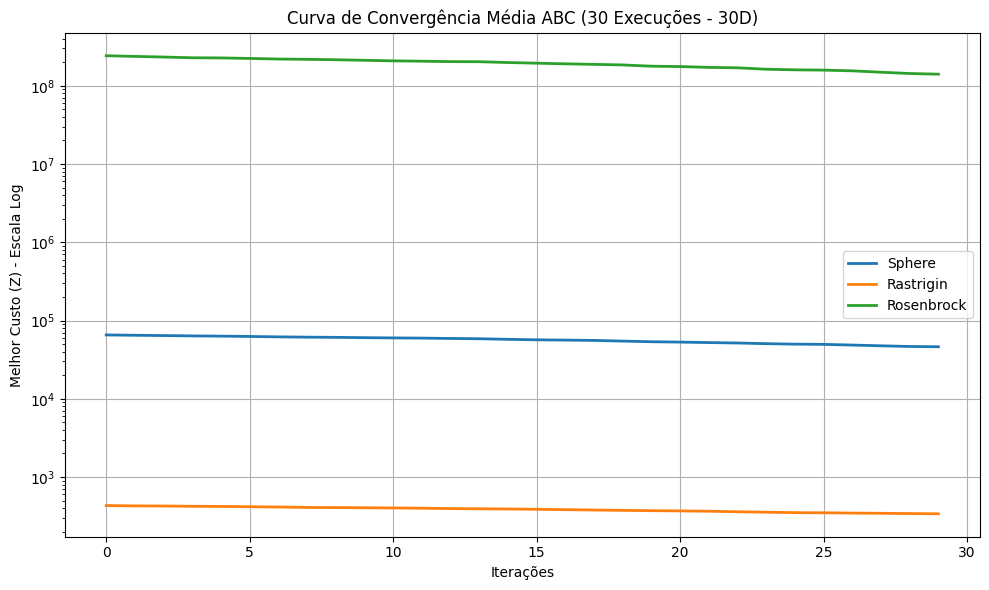

In [6]:
#rodar
artificial_bee_colony(selection_mode=SELECTION_MODE)